In [1]:
import sys, os, yaml
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.utils.GraphGradCAM import *

p:\Anaconda\envs\torch_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.datasets.gqa_graph_dataset import GQAGraphDataset
from src.models.gnn import GCNEmbeddingNet, GINEEmbeddingNet

## Caricamento modelli

In [3]:
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gcn_config.yaml")
with open(config_path) as f:
    cfg_gcn = yaml.safe_load(f)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path  = os.path.join(BASE_DIR, cfg_gcn["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gcn = checkpoint["node_vocab"]
rel_vocab_gcn  = checkpoint["rel_vocab"]

gcn_model = GCNEmbeddingNet(
    num_node_types=len(node_vocab_gcn) + 1,
    emb_dim=cfg_gcn["model"]["emb_dim"],
    hidden_dim=cfg_gcn["model"]["hidden_dim"],
    num_layers=cfg_gcn["model"]["num_layers"],
    dropout=cfg_gcn["model"]["dropout"],
    use_bbox=cfg_gcn["model"]["use_bbox"],
    node_emb_dim=cfg_gcn["model"]["node_emb_dim"],
).to(device)
gcn_model.load_state_dict(checkpoint["model_state_dict"])
gcn_model.eval()
print(f"GCN caricato da: {ckpt_path}")

GCN caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gcn20.pth


In [4]:
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gine_config.yaml")
with open(config_path) as f:
    cfg_gine = yaml.safe_load(f)

ckpt_path  = os.path.join(BASE_DIR, cfg_gine["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gine = checkpoint["node_vocab"]
rel_vocab_gine  = checkpoint["rel_vocab"]

gine_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab_gine) + 1,
    edge_vocab_size=len(rel_vocab_gine),
    emb_dim=cfg_gine["model"]["emb_dim"],
    hidden_dim=cfg_gine["model"]["hidden_dim"],
    num_layers=cfg_gine["model"]["num_layers"],
    dropout=cfg_gine["model"]["dropout"],
    use_bbox=cfg_gine["model"]["use_bbox"],
    node_emb_dim=cfg_gine["model"]["node_emb_dim"],
).to(device)
gine_model.load_state_dict(checkpoint["model_state_dict"])
gine_model.eval()
print(f"GINE caricato da: {ckpt_path}")

GINE caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gnn20.pth


## Dataset di validazione

In [5]:
df_train = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["train_csv"]))
df_val   = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["val_csv"]))

all_labels = df_train["labels"].unique()
label2idx  = {l: i for i, l in enumerate(all_labels)}
idx2label  = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"]   = df_val["labels"].map(label2idx)

val_dataset_gcn = GQAGraphDataset(
    df=df_val, label_col="labels",
    node_vocab=node_vocab_gcn, rel_vocab=rel_vocab_gcn,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"],
)
val_dataset_gine = GQAGraphDataset(
    df=df_val, label_col="labels",
    node_vocab=node_vocab_gine, rel_vocab=rel_vocab_gine,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gine["model"]["use_bbox"],
)

IMAGE_DIR = os.path.join(BASE_DIR, "data", "images")
print(f"Val dataset size: {len(val_dataset_gcn)}")

Val dataset size: 3208


In [6]:
# 1. Istanzia il dataset di training (assicurati che usi lo stesso vocabolario)
train_dataset_gcn = GQAGraphDataset(
    df=df_train, label_col="labels",
    node_vocab=node_vocab_gcn, rel_vocab=rel_vocab_gcn,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"],
)

train_dataset_gine = GQAGraphDataset(
    df=df_train, label_col="labels",
    node_vocab=node_vocab_gine, rel_vocab=rel_vocab_gine,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gine["model"]["use_bbox"],
)

print(f"Train dataset size: {len(train_dataset_gcn)}")

# 2. Estrai gli embedding SOLO dal training set per costruire i prototipi
print("Building GCN training embeddings for prototypes...")
train_embs_gcn = build_gallery_embeddings(gcn_model, train_dataset_gcn, device, model_type="gcn")

print("Building GINE training embeddings for prototypes...")
train_embs_gine = build_gallery_embeddings(gine_model, train_dataset_gine, device, model_type="gine")

# 3. Calcola i prototipi stabili usando le label del training set
prototypes_gcn  = compute_class_prototypes(train_embs_gcn, df_train["labels"].values)
prototypes_gine = compute_class_prototypes(train_embs_gine, df_train["labels"].values)

print("Prototipi calcolati correttamente dal TRAINING SET.")

Train dataset size: 22482
Building GCN training embeddings for prototypes...
Building GINE training embeddings for prototypes...
Prototipi calcolati correttamente dal TRAINING SET.


## 1 · GraphGrad-CAM — Node Importance Aggregata per Classe

Aggreghiamo l'importanza Grad-CAM su **N campioni per classe** e mediamo per tipo di nodo.

Questo risponde alla domanda corretta:
> *"Per riconoscere oggetti della classe X, su quali tipi di nodo si concentra il modello in media?"*

L'aggregazione per tipo di nodo è necessaria perché grafi diversi hanno strutture
diverse: mediare per indice sarebbe scorretto.

In [7]:
TARGET_CLASSES        = [3, 10, 4]   
NUM_SAMPLES_PER_CLASS = 30            

with GraphGradCAM(gcn_model,  gcn_model.convs[-1])  as cam_gcn, \
     GraphGradCAM(gine_model, gine_model.convs[-1]) as cam_gine:

    results_gcn = aggregate_node_importance_by_class(
        cam=cam_gcn,
        dataset=val_dataset_gcn,
        node_vocab=node_vocab_gcn,
        df=df_val,
        target_classes=TARGET_CLASSES,
        prototypes=prototypes_gcn, # <--- Nuovo parametro
        device=device,
        num_samples_per_class=NUM_SAMPLES_PER_CLASS,
        use_edge_attr=False,   
    )

    results_gine = aggregate_node_importance_by_class(
        cam=cam_gine,
        dataset=val_dataset_gine,
        node_vocab=node_vocab_gine,
        df=df_val,
        target_classes=TARGET_CLASSES,
        prototypes=prototypes_gine, # <--- Nuovo parametro
        device=device,
        num_samples_per_class=NUM_SAMPLES_PER_CLASS,
        use_edge_attr=True,    
    )

print("Hook rimossi e mappe basate su prototipi calcolate.")

p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
p:\Anaconda\envs\torch_new\Lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
p:\Uni\mujoco\dl26-projects\src\utils\GraphGradCAM.py:97: RuntimeWarning: Gradienti nulli per questo sample: importanza posta a zero.
  warnings.warn("Gradienti nulli per questo sample: importanza posta a zero.", RuntimeWarning)


Hook rimossi e mappe basate su prototipi calcolate.


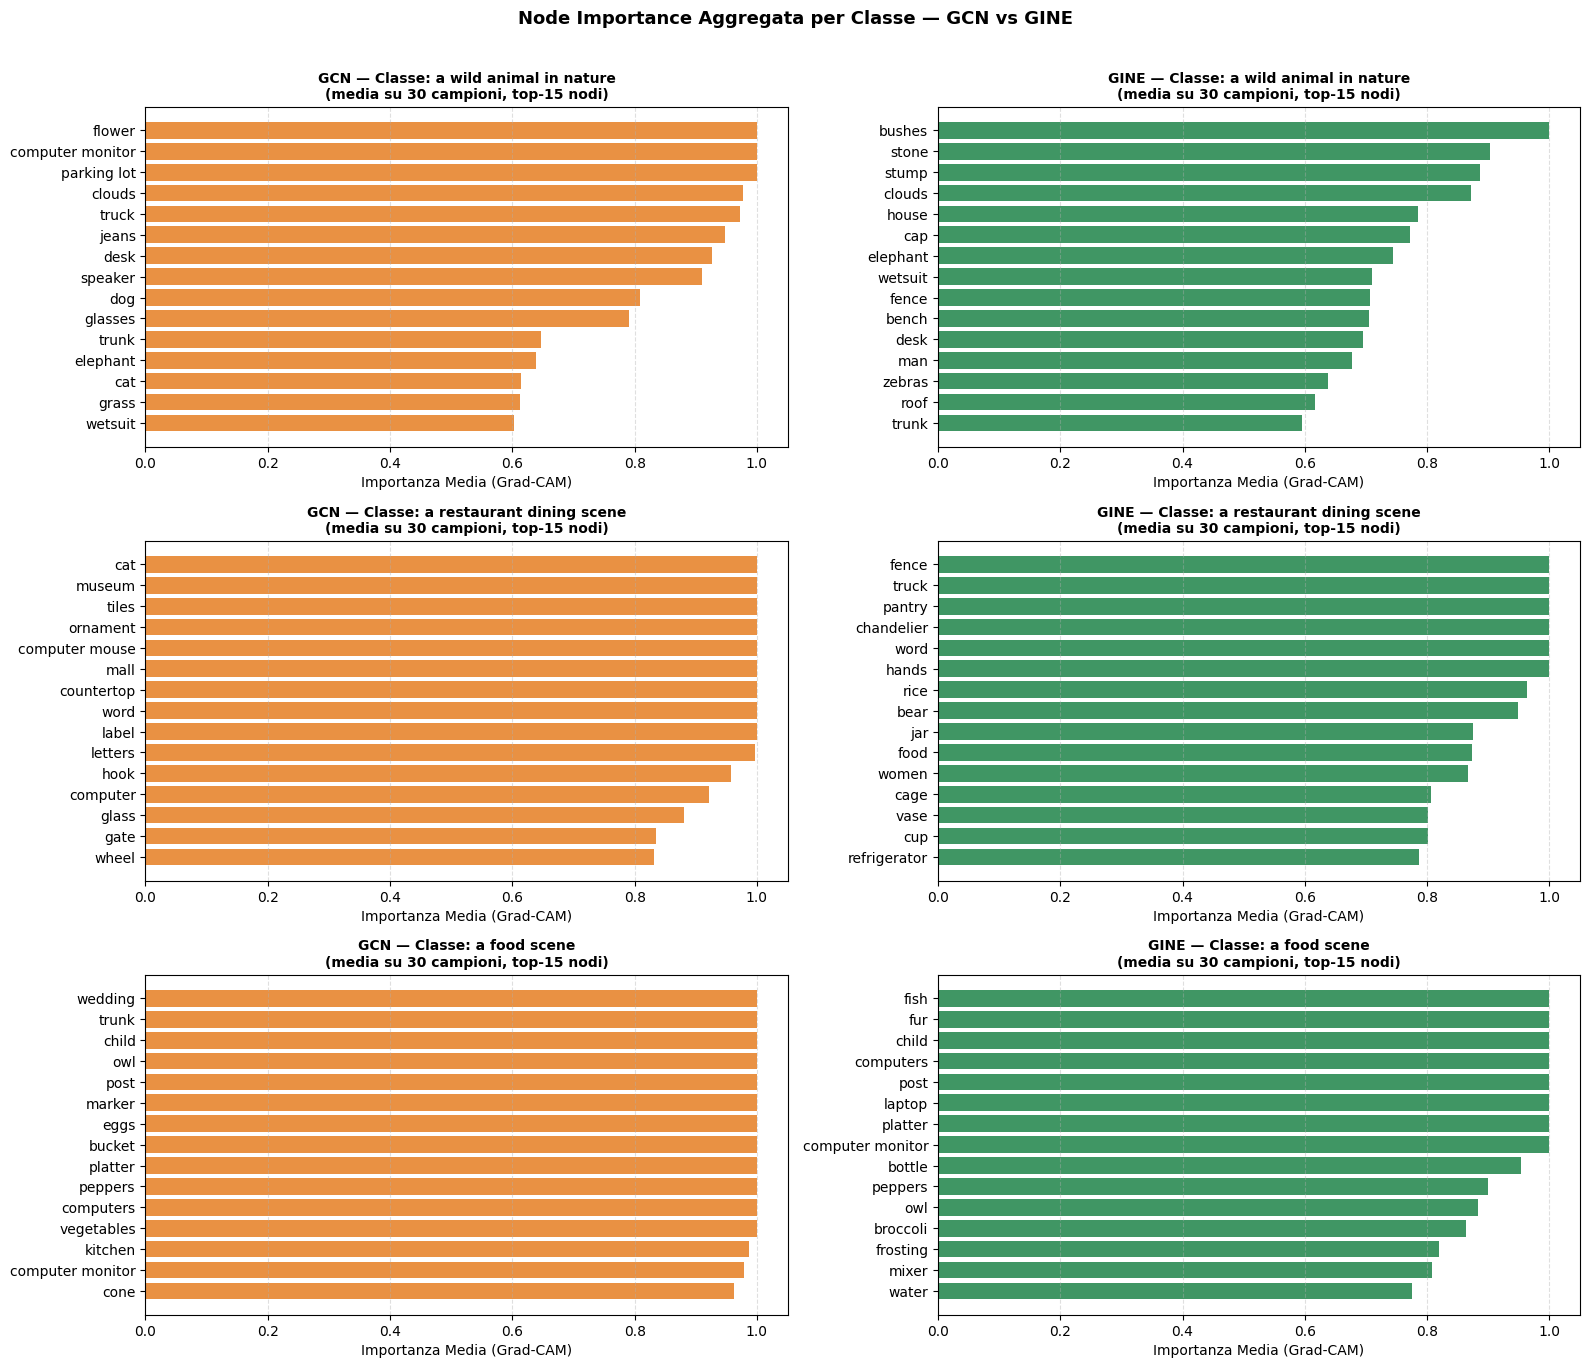

In [15]:
plot_node_importance_by_class(
    results_gcn=results_gcn,
    results_gine=results_gine,
    idx2label=idx2label,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,
    topk=15,
)

## 2 · Studio Globale Archi — GINE (GNNExplainer)

GNNExplainer ottimizza una edge mask per ogni sample e spiega quale sottoinsieme
di archi è sufficiente a riprodurre l'output. Aggregando su più campioni otteniamo
una stima dell'importanza media per tipo di relazione.

**Limite**: misura correlazione, non impatto causale sul ranking.
Vedere la Sezione 3 per la misura causale.

Analisi archi (GINE — GNNExplainer) su 50 campioni...


p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


          Relazione  Importanza Media  Conteggio
5                of          0.349507         32
6                in          0.335463         44
7                on          0.334399         92
8       in front of          0.332520         14
10          wearing          0.331879         66
12             with          0.316019         20
13             near          0.302728         44
14        on top of          0.296992         18
15            below          0.295191         26
16   to the left of          0.284127       2078
18  to the right of          0.278648       2078
19           behind          0.276937         14


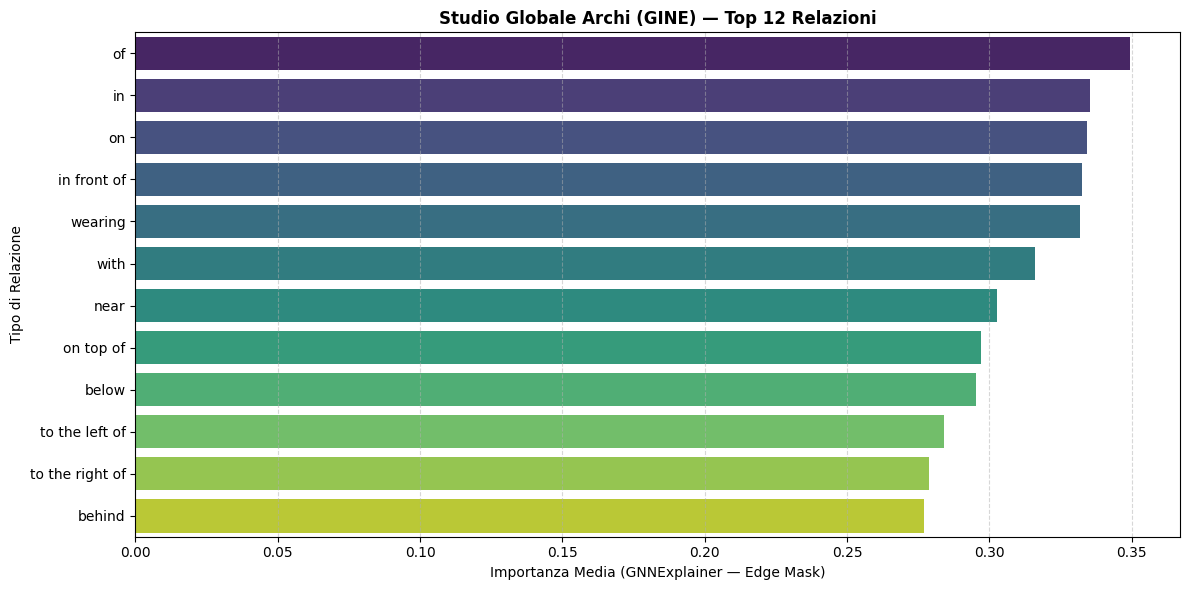

In [9]:
df_edges_gine = analyze_global_edge_importance_with_explainer(
    dataset_gine=val_dataset_gine,
    model_gine=gine_model,
    rel_vocab_gine=rel_vocab_gine,
    device=device,
    num_samples=50,
)

# 1. Filtra il DataFrame di GINE escludendo relazioni con meno di 5 apparizioni
df_edges_gine_clean = df_edges_gine[df_edges_gine['Conteggio'] >= 5]

# 2. Mostra le prime 12 o 15 relazioni rimaste (saranno tutte stabilissime!)
print(df_edges_gine_clean.head(12))

# 3. Disegna il grafico finale pulito solo per GINE
plot_global_edge_study(df_edges_gine_clean, topk=12, model_name="GINE")

## 3 · Studio Globale Archi — GCN (GNNExplainer)

Analisi archi (GCN — GNNExplainer) su 50 campioni...


p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


              Relazione  Importanza Media  Conteggio
0          fish → plate          0.654083          7
1      airplane → wings          0.568108          5
2      wings → airplane          0.565729          5
3          plate → fish          0.556805          7
4   elephant → elephant          0.521407         20
5            tail → cat          0.494715          5
6             ear → ear          0.466022          8
7   airplane → airplane          0.457082         12
8         hair → window          0.454574          6
9       building → tree          0.440078          6
10        cliff → cliff          0.439685          8
11      pole → building          0.428833          6
12        tree → leaves          0.428176          8
13        leaves → tree          0.423122          8
14        books → books          0.391688          8


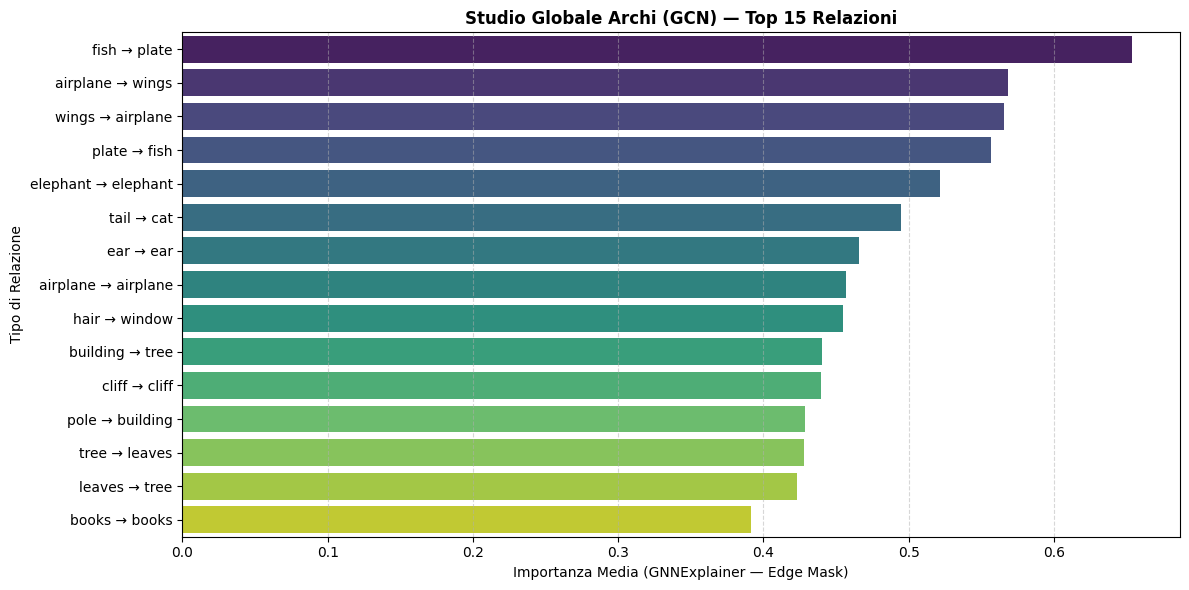

In [10]:
# Nel tuo Notebook, modifica la cella del punto 3 così:
df_edges_gcn = analyze_global_edge_importance_gcn(
    dataset_gcn=val_dataset_gcn,
    model_gcn=gcn_model,
    node_vocab_gcn=node_vocab_gcn,
    device=device,
    num_samples=50,  
    min_count=5       # <--- Filtra le relazioni che appaiono meno di 5 volte su 50 grafi
)

print(df_edges_gcn.head(15))
plot_global_edge_study(df_edges_gcn, topk=15, model_name="GCN")

## 4 · Focal Point Analysis — Impatto Causale sul Ranking

Le sezioni precedenti misurano correlazioni tra struttura del grafo e output.
La **Focal Point Analysis** risponde alla domanda causale:

> *"Se questa relazione non esistesse, il ranking dei vicini cambierebbe?"*

Ogni tipo di relazione viene rimosso dall'input e si misura la disruption
del top-k ranking nello spazio metrico.

**Step 1** — costruiamo la gallery degli embedding sul validation set.

**FIX rispetto alla versione precedente**: `build_gallery_embeddings` accetta
ora `model_type` per usare la firma corretta di GCN (`no num_graphs`) e GINE.

In [11]:
print("Building GCN gallery embeddings...")
gallery_embs_gcn  = build_gallery_embeddings(
    gcn_model, val_dataset_gcn, device, model_type="gcn"
)
print("Building GINE gallery embeddings...")
gallery_embs_gine = build_gallery_embeddings(
    gine_model, val_dataset_gine, device, model_type="gine"
)
print(f"Gallery GCN:  {gallery_embs_gcn.shape}")
print(f"Gallery GINE: {gallery_embs_gine.shape}")

Building GCN gallery embeddings...
Building GINE gallery embeddings...
Gallery GCN:  torch.Size([3208, 128])
Gallery GINE: torch.Size([3208, 128])


### 4a · Robustness by Relation Type — Delta Embedding

Prima misura: quanto si sposta l'embedding (norma L2) quando si rimuove
ogni tipo di relazione. Un delta alto = relazione strutturalmente critica.

In [12]:
NUM_SAMPLES = 100

print("Robustness GINE...")
rob_gine = robustness_by_relation_type(
    gine_model, val_dataset_gine, rel_vocab_gine, device,
    num_samples=NUM_SAMPLES, model_type="gine"
)
print("\nTop-10 relazioni critiche (delta embedding) — GINE:")
print(rob_gine.head(10).to_string())

Robustness GINE...

Top-10 relazioni critiche (delta embedding) — GINE:
to the left of     0.102164
to the right of    0.090513
on                 0.051016
in                 0.023119
wearing            0.020347
of                 0.012233
near               0.010031
in front of        0.006184
on top of          0.005762
lying on           0.004492


### 4b · Focal Point Analysis — Ranking Disruption

Misura più rilevante per retrieval: quanto cambia il top-k ranking
quando si rimuove ogni tipo di relazione.

`Disruption = 1 − overlap(top-k base, top-k perturbed)`

In [13]:
TOPK = 10

print("Focal Point Analysis — GINE...")
focal_gine = focal_point_analysis(
    gine_model, val_dataset_gine, gallery_embs_gine, rel_vocab_gine,
    device=device, topk=TOPK, num_samples=NUM_SAMPLES, model_type="gine"
)

print("\nTop-10 focal point relazioni — GINE:")
print(focal_gine.head(10).to_string())

Focal Point Analysis — GINE...

Top-10 focal point relazioni — GINE:
to the left of     0.542857
to the right of    0.485714
on                 0.245918
wearing            0.128571
in                 0.121429
near               0.069388
of                 0.063918
on top of          0.044898
in front of        0.036735
holding            0.029592


### 4d · Distribuzione Disruption — Relazione più critica

Verifica che la media non nasconda effetti bimodali.

Relazione più critica (GINE): 'to the left of'


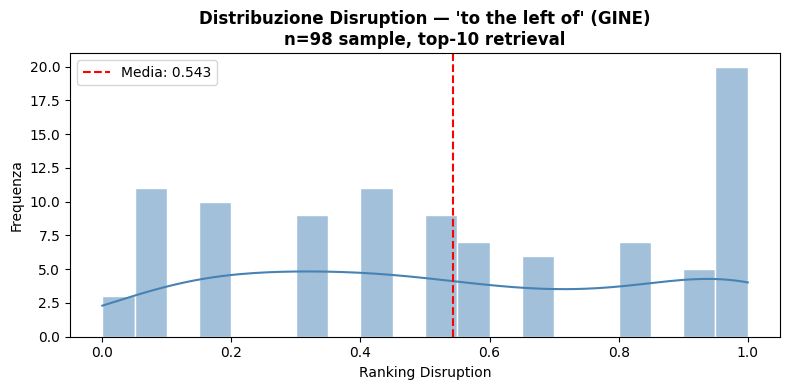

In [14]:
top_rel = focal_gine.index[0]
print(f"Relazione più critica (GINE): '{top_rel}'")

plot_disruption_distribution(
    gine_model, val_dataset_gine, gallery_embs_gine,
    rel_vocab=rel_vocab_gine,
    rel_name=top_rel,
    device=device,
    topk=TOPK,
    num_samples=NUM_SAMPLES,
    model_name="GINE",
    model_type="gine",
)